In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

In [2]:
data=pd.read_csv("dataset/Heart.csv")

In [3]:
data.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [4]:
from sklearn.preprocessing import LabelEncoder
encoder= LabelEncoder()
data['HD']=  encoder.fit_transform(data['Heart Disease'])
data[['Heart Disease', 'HD']].head()

,Heart Disease,HD
0,Presence,1
1,Absence,0
2,Presence,1
3,Absence,0
4,Absence,0


In [5]:
data

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease,HD
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,Absence,0
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,Absence,0
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,Absence,0
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,Absence,0


In [6]:
data = data.drop(columns=["Heart Disease"])


In [7]:
data

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,HD
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,0
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,0
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,0
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,0


In [8]:
data["HD"].value_counts()

HD
0    150
1    120
Name: count, dtype: int64

In [9]:
data.isnull().sum()


Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
HD                         0
dtype: int64

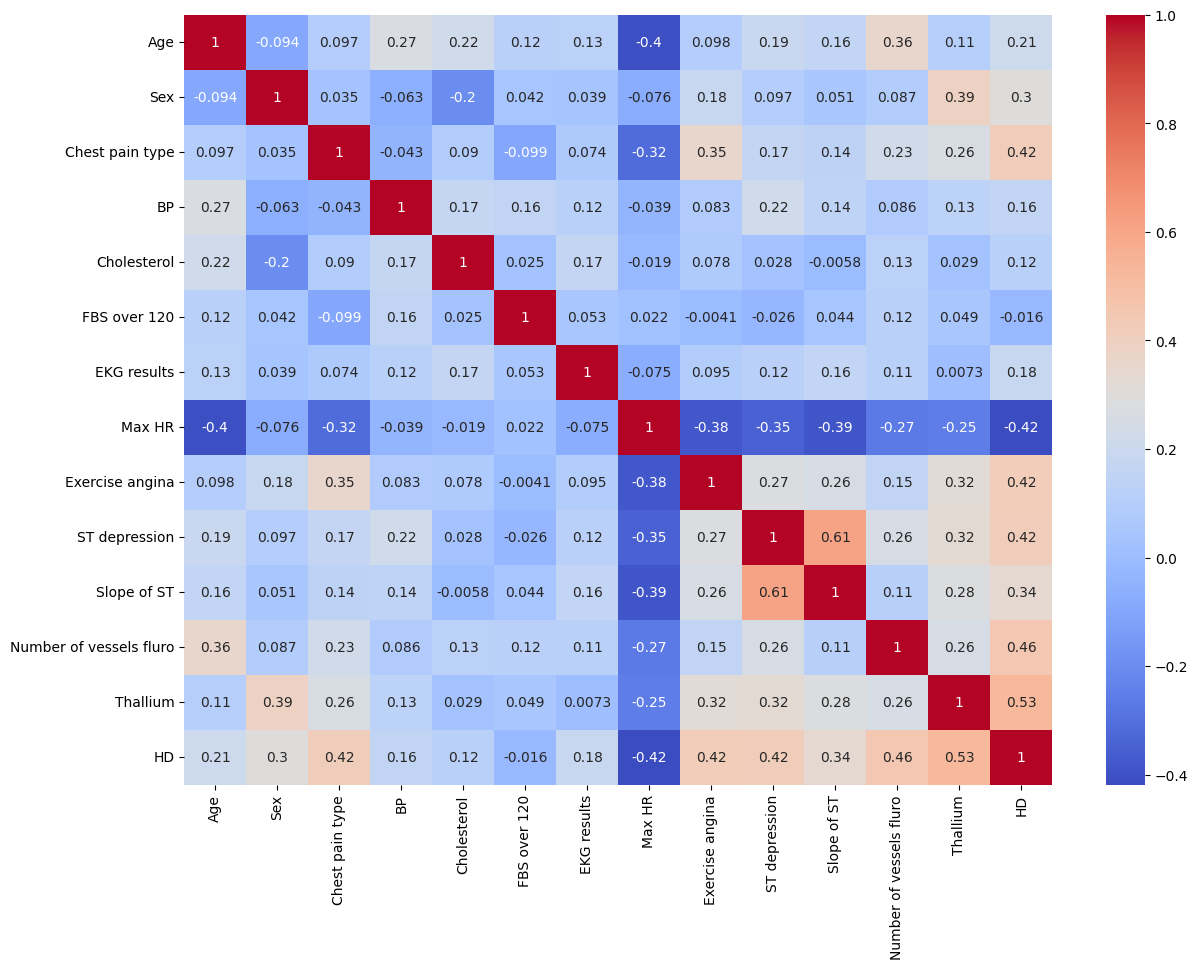

In [10]:

numeric_data = data.select_dtypes(include="number")
cors=numeric_data.corr()
plt.figure(figsize=(14, 10)) 
sns.heatmap(cors, annot=True, cmap="coolwarm")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

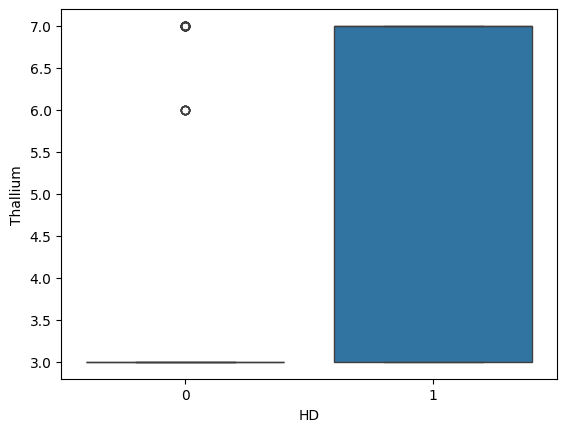

In [11]:
sns.boxplot(x="HD", y="Thallium", data=data)
plt.show

<Axes: xlabel='HD', ylabel='Number of vessels fluro'>

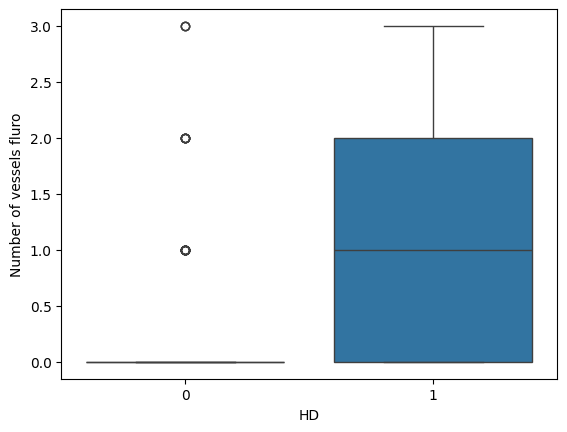

In [12]:
sns.boxplot(x="HD", y="Number of vessels fluro", data=data)



<Axes: xlabel='HD', ylabel='ST depression'>

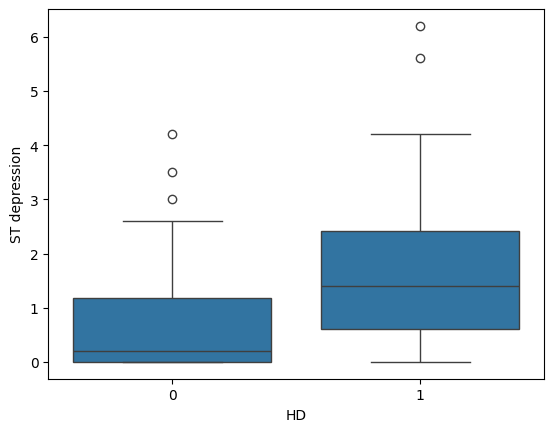

In [13]:
sns.boxplot(x="HD", y="ST depression", data=data)


<Axes: xlabel='HD', ylabel='Max HR'>

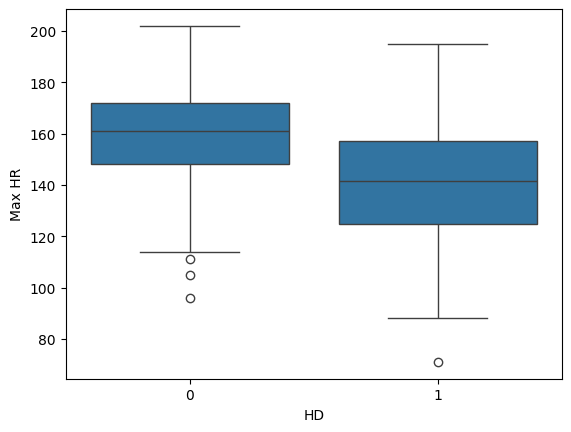

In [14]:
sns.boxplot(x="HD", y="Max HR", data=data)

| Feature       | HD=0 (Healthy) | HD=1 (Disease) |
| ------------- | -------------- | -------------- |
| Vessels fluro | Mostly 0       | 1–3            |
| ST depression | Near 0         | High           |
| Max HR        | High           | Low            |


In [15]:
y= data['HD']
x = data[['Age',
          'Sex',
          'Chest pain type',
          'BP',
          'Cholesterol',
          'FBS over 120',
          'EKG results',
          'Max HR',
          'Exercise angina',
          'ST depression',
          'Slope of ST',
          'Number of vessels fluro',
          'Thallium']]


In [16]:
from sklearn.model_selection import train_test_split
x_tr,x_ts,y_tr,y_ts= train_test_split(x,y,test_size=0.2,random_state=42)
from sklearn.preprocessing import StandardScaler
scaling= StandardScaler()
scaling.fit(x_tr)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [17]:
from sklearn.linear_model import LogisticRegression
model= LogisticRegression()
model.fit(x_tr,y_tr)
model.score(x_ts,y_ts) #accuracy correct/total prediction

c:\Users\Machine learning\Heart\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9074074074074074

In [18]:
model.coef_ #kis ka  kitna weight hai ya kis pe kitna depend krta hai

array([[-0.05188335,  0.52840454,  0.40053642,  0.01263367,  0.00332731,
        -0.30946838,  0.14547877, -0.03110129,  0.51656553,  0.5249142 ,
         0.15985485,  0.91096309,  0.35294936]])

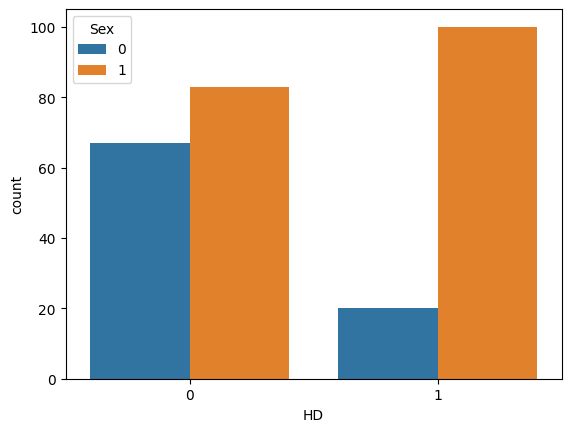

In [19]:
sns.countplot(x="HD", hue="Sex", data=data)
plt.show()


This defines that dataset is unfair, we need to drop sex because there is no medical evidence that says heart disease is more common in males, our accuracy may drop a bit but it will be fair and trusted model

In [20]:
data = data.drop(columns=["Sex"])

In [21]:
data.columns

Index(['Age', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'HD'],
      dtype='object')

less again predict the model with no sex

In [22]:
y1= data['HD']
x1 = data[['Age',
          'Chest pain type',
          'BP',
          'Cholesterol',
          'FBS over 120',
          'EKG results',
          'Max HR',
          'Exercise angina',
          'ST depression',
          'Slope of ST',
          'Number of vessels fluro',
          'Thallium']]


In [23]:
from sklearn.model_selection import train_test_split
x_tr1,x_ts1,y_tr1,y_ts1= train_test_split(x1,y1,test_size=0.2,random_state=42)
from sklearn.preprocessing import StandardScaler
scaling= StandardScaler()
scaling.fit(x_tr1)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [24]:
from sklearn.linear_model import LogisticRegression
model1= LogisticRegression()
model1.fit(x_tr1,y_tr1)
model1.score(x_ts1,y_ts1) #accuracy correct/total prediction

c:\Users\Machine learning\Heart\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8888888888888888

Accuracy went down a bit but atleast it is fair

In [25]:
from sklearn.pipeline import make_pipeline
pipeL=[]
test_score=[]
for lam in np.arange(0.01,100,0.1):
    pipe= make_pipeline(StandardScaler(), LogisticRegression(C=1/lam))
    pipe.fit(x_tr1,y_tr1)
    scores=pipe.score(x_ts1,y_ts1)
    pipeL.append(pipe)
    test_score.append(scores)

  

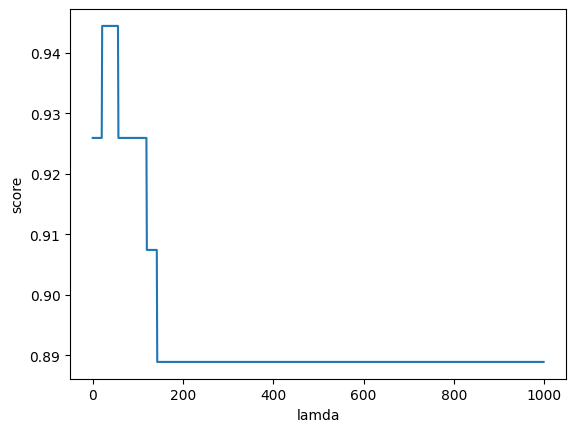

In [26]:
plt.xlabel("lamda")
plt.ylabel("score")
plt.plot(test_score)

In [27]:
best_score=np.argmax(test_score)
best_score

np.int64(21)

In [28]:
l_best=0.001*best_score*0.1

In [29]:
l_best


np.float64(0.0021000000000000003)

In [30]:
test_score[best_score] 

0.9444444444444444

previously our accuracy was 88 after finding best lambda value it is now 94 huge impact

In [31]:
best_pl=pipeL[best_score]

In [32]:
best_pl.score(x_ts1,y_ts1)

0.9444444444444444

In [33]:
y_pred = best_pl.predict(x_ts1)


In [34]:
print(classification_report(y_ts1,y_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        33
           1       1.00      0.86      0.92        21

    accuracy                           0.94        54
   macro avg       0.96      0.93      0.94        54
weighted avg       0.95      0.94      0.94        54



In [35]:
import pickle

pickle.dump(best_pl, open("heart_disease_model.pkl", "wb"))


In [36]:
import pickle

loaded_model = pickle.load(open("heart_disease_model.pkl", "rb"))

loaded_model.score(x_ts1, y_ts1)


0.9444444444444444